# Imputation Tester

The ultimate way to test impuation methods is to attach them to your model and evaluate the performance as a whole. But I would still like to evaluate them independantly.

Here we will use data points with full x-values, remove some, and then impute them and see how each impyter does. This means we will be training on entirely different points than we want to use it on, including some points that do not have y values. 

Is this better than just putting it in the model? Should we train and evaluate here, then save and reload for actual use? UNsure. For now, let's load our data and make our filter-related cutoffs:

In [1]:
import numpy as np
import pandas as pd
from pandas.plotting import scatter_matrix
import sys
sys.path.append('..')
from Utilities import custom
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from IPython.core.magic import register_cell_magic
import matplotlib as mpl
import matplotlib.pyplot as plt

@register_cell_magic
def skip(line, cell):
    return

df=custom.data_loader('FULL')
filters=[column for column in df.columns if 'W_abs' in column]
other_xs=['Fe/H', 'age_Kruijssen']
attributes=filters+other_xs
df=df[attributes+['NGC']]
df[attributes].describe()

,F275W_abs,F336W_abs,F438W_abs,F606W_abs,F814W_abs,Fe/H,age_Kruijssen
count,842.000000,845.000000,826.000000,1042.000000,1045.000000,821.000000,1050.000000
mean,4.635800,2.185686,1.609668,0.128532,-0.881991,-1.476091,11.956133
std,1.419282,5.679925,1.325944,1.588503,1.618605,0.525838,0.723156
min,2.263662,-111.336932,-1.161438,-2.886038,-4.195690,-2.448000,10.490000
25%,3.686921,1.568501,0.576257,-1.014581,-2.066690,-1.910000,11.520000
50%,4.282261,2.225601,1.606313,0.100995,-0.872360,-1.470000,12.050000
75%,5.273753,3.036662,2.429723,1.041968,0.132001,-1.150000,12.520000
max,14.220168,12.240468,9.921285,9.645368,8.108690,0.231000,13.060000


In [2]:
cutoffs={'F275W_abs':8.5, 'F336W_abs':6., 'F438W_abs': 6., 'F606W_abs': 4., 'F814W_abs': 3.}
masks=[df[key]>value for key, value in cutoffs.items()]
remove=np.logical_or.reduce(masks)
df=df[~remove]


filters=[column for column in df.columns if 'W_abs' in column]
other_xs=['Fe/H', 'age_Kruijssen']
attributes=filters+other_xs
df=df[attributes+['NGC']]

### KNN Imputation

Other, simpler forms of impuation (like w/mean) should jus be tsted with model, not wroth exploring in further detail here. Start with KNN. First, will need to select only points with full filter values:

In [3]:
df_KNN=df.dropna(how='any')
train_KNN, test_KNN=custom.train_test_split(df_KNN, test_size=0.2)

Using 20.0 percent of the passed df as test size, not necessarily 20.0 percent of the full dataset


In [4]:
train_KNN.drop('NGC', axis=1, inplace=True)
test_KNN.drop('NGC', axis=1, inplace=True)

For now, start with standard scaler:

In [5]:
KNN_scaler=StandardScaler().fit(train_KNN)
train_KNN_scaled=pd.DataFrame(KNN_scaler.transform(train_KNN), columns=train_KNN.columns)
train_KNN_scaled.corr()

,F275W_abs,F336W_abs,F438W_abs,F606W_abs,F814W_abs,Fe/H,age_Kruijssen
F275W_abs,1.000000,0.123050,0.553286,0.275243,0.150470,0.819729,-0.129084
F336W_abs,0.123050,1.000000,0.139022,0.113613,0.101217,0.105014,-0.020353
F438W_abs,0.553286,0.139022,1.000000,0.947438,0.894893,0.313860,0.077392
F606W_abs,0.275243,0.113613,0.947438,1.000000,0.989920,0.089370,0.124296
F814W_abs,0.150470,0.101217,0.894893,0.989920,1.000000,0.003872,0.130475
Fe/H,0.819729,0.105014,0.313860,0.089370,0.003872,1.000000,-0.419945
age_Kruijssen,-0.129084,-0.020353,0.077392,0.124296,0.130475,-0.419945,1.000000


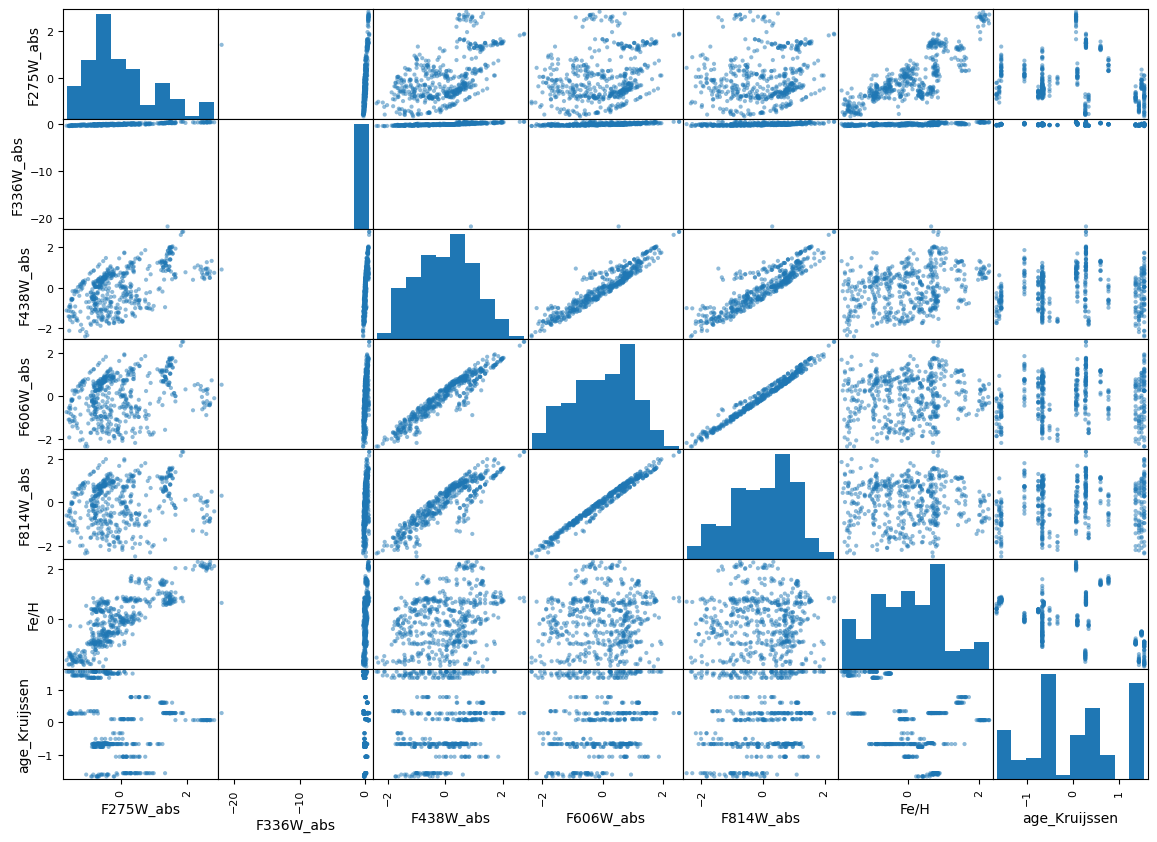

In [6]:
scatter_matrix(train_KNN_scaled, figsize=(14, 10))
plt.show()

In [7]:
train_KNN_scaled.describe()

,F275W_abs,F336W_abs,F438W_abs,F606W_abs,F814W_abs,Fe/H,age_Kruijssen
count,5.010000e+02,5.010000e+02,5.010000e+02,5.010000e+02,5.010000e+02,5.010000e+02,5.010000e+02
mean,4.786590e-16,-2.127373e-17,1.684171e-17,-1.152327e-17,-6.736683e-17,1.276424e-16,4.573853e-16
std,1.001000e+00,1.001000e+00,1.001000e+00,1.001000e+00,1.001000e+00,1.001000e+00,1.001000e+00
min,-1.620530e+00,-2.187221e+01,-2.408190e+00,-2.358508e+00,-2.478323e+00,-1.883768e+00,-1.660587e+00
25%,-6.909508e-01,-1.113262e-01,-7.669363e-01,-7.329328e-01,-7.424627e-01,-8.349222e-01,-6.652196e-01
50%,-2.925813e-01,1.704157e-02,5.521139e-02,1.304444e-01,9.938227e-02,-6.028480e-03,7.048685e-02
75%,4.610571e-01,1.489903e-01,7.077445e-01,7.469662e-01,7.801707e-01,7.047428e-01,6.042347e-01
max,2.801363e+00,5.903249e-01,2.760745e+00,2.526655e+00,2.315076e+00,2.279030e+00,1.556325e+00


In [8]:
train_KNN.describe()

,F275W_abs,F336W_abs,F438W_abs,F606W_abs,F814W_abs,Fe/H,age_Kruijssen
count,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000
mean,4.547871,2.157972,1.594810,0.081916,-0.902035,-1.517040,11.981138
std,1.348751,5.194186,1.145675,1.259661,1.330314,0.491507,0.693904
min,2.364362,-111.336932,-1.161438,-2.886038,-4.195690,-2.442000,10.830000
25%,3.616881,1.580301,0.717027,-0.840409,-1.888757,-1.927000,11.520000
50%,4.153645,2.246401,1.658001,0.246068,-0.769957,-1.520000,12.030000
75%,5.169101,2.931083,2.404845,1.021901,0.134801,-1.171000,12.400000
max,8.322440,5.221168,4.754568,3.261468,2.174668,-0.398000,13.060000
